# LSTM - NASDAQ-100 Microstructure

A long short-term memory network reads the window one observation at a time
and carries a running summary forward, deciding at each step how much of that
summary to keep and how much of the new observation to admit. Those decisions
are learned rather than fixed, which is what lets the model hold on to
something that happened early in the window if it turns out to matter, and
discard it otherwise.

That is a real difference from a model that maps a flattened window through one
linear layer: the same feature carries different weight depending on what
preceded it. Whether it is a *useful* difference on order-flow features at this
horizon is the question the fit answers.

The label looks 15 minutes ahead on a one-minute grid, so consecutive windows
overlap heavily and neighbouring rows are far from independent. That shapes
everything below: how windows are built, where folds are cut, and how much of
the training set is sampled.

**Learning Objectives**:
- Fit a recurrent sequence model on a panel by declaring one request rather
  than assembling folds and windows in the notebook
- Read a learning curve across training epochs and say what it shows about
  capacity and noise
- Check that a fitted model produced predictions on every fold it was asked
  for, before any of those predictions are used

**Book Reference**: Chapter 13

**Prerequisites**: [`05_evaluation`](05_evaluation.ipynb)

**What it writes**: one training run per label and one complete validation prediction set per
label and checkpoint, in `run_log/registry.db` and under `run_log/training/` and
`run_log/predictions/`, grouped under a population this notebook alone publishes.
[`13_model_analysis`](13_model_analysis.ipynb) reads that population beside the other
families. **It selects nothing**: selection is validation backtest Sharpe in
[`14_backtest`](14_backtest.ipynb).

In [1]:
"""Fit the declared NASDAQ-100 microstructure LSTM population on the walk-forward folds."""

import plotly.graph_objects as go
import polars as pl

from case_studies.research import (
    declared_labels,
    load_model_configs,
    model_requests,
    open_study,
    resolved_model_plan,
    run_model_population,
)
from utils.style import COLORS, show_plotly_with_alt

In [2]:
LABELS: list[str] = []
EXECUTION_TIER = "canonical"
WORKSPACE: str = ""
PREVIEW_REDUCTIONS: dict = {}
CONFIG_NAMES: list[str] = []
POPULATION_NAME = ""
SUPERSEDES_POPULATION: str = ""
DEVICE: str = ""

In [3]:
study = open_study(
    "nasdaq100_microstructure",
    execution_tier=EXECUTION_TIER,
    workspace=WORKSPACE or None,
    entry_point="09_dl_lstm",
)

## 1. Which labels, and which model

The labels are the ones whose training menu declares `deep_learning`, and fitting all of them
in one run is what makes this population comparable against the linear and gradient boosting
ones: the families differ, the targets do not. `fwd_ret_15m` is the return over the fifteen
minutes after the decision minute and the horizon the strategy chapters trade; `fwd_ret_5m`
and `fwd_ret_60m` are the same construction at shorter and longer horizons.

The classification label `fwd_dir_15m` is absent, and not by oversight. The sequence runner
refuses a non-regression label outright - `case_studies/utils/deep_learning.py`, "sequence
runner currently supports regression labels only" - so that label declares `linear` and `gbm`
and nothing else.

In [4]:
declared_labels(study, "deep_learning")

('fwd_ret_15m', 'fwd_ret_5m', 'fwd_ret_60m')

`lstm_h64` is this notebook's slice of the declared family. The menu declares four
architectures and each has its own notebook, because each is a different claim about what
structure in the window matters. They resolve against the same menu, the same folds and the
same windows, so a difference between their results is a difference between architectures.

`lookback` is how many prior one-minute observations enter a window - 60 gives the model the
trailing hour - and it is the same across all four, so the sample they are measured on is the
same. `n_epochs` and `checkpoint_interval` are declared with the architecture rather than
passed in here, because together they decide how many prediction sets each configuration owes:
100 epochs saved every 5 is 20, and a run that quietly trained for fewer would publish a
different population under the same name.

In [5]:
SEQUENCE_CONFIG = "lstm_h64"
declared = load_model_configs(study, "deep_learning", config_names=[SEQUENCE_CONFIG])
configs = load_model_configs(
    study,
    "deep_learning",
    labels=LABELS or None,
    config_names=CONFIG_NAMES or [SEQUENCE_CONFIG],
)
configs

family,label,config_name,model_class,params
str,str,str,str,str
"""deep_learning""","""fwd_ret_15m""","""lstm_h64""","""""","""architecture=lstm, dropout=0.1…"
"""deep_learning""","""fwd_ret_5m""","""lstm_h64""","""""","""architecture=lstm, dropout=0.1…"
"""deep_learning""","""fwd_ret_60m""","""lstm_h64""","""""","""architecture=lstm, dropout=0.1…"


`LABELS` and `CONFIG_NAMES` narrow the run below this notebook's own slice, and a narrowed run
declares a different member set than the published population does. A population is immutable
once written, so such a run must publish under its own name.

The device is checked in the same cell, because it is inside the training identity rather than
beside it: a network trained on a GPU and the same network trained on a CPU accumulate their
sums in different orders and reach different weights. The runner refuses to substitute a CPU
for a requested GPU rather than publishing a different model under the published name, so on a
machine with no NVIDIA card this notebook stops at the next cell; set `DEVICE="cpu"` and pass a
`POPULATION_NAME` to fit the same grid there.

In [6]:
PUBLISHED_DEVICE = "gpu"
device = DEVICE or PUBLISHED_DEVICE
print(f"training device: {device}")

narrows = set(zip(configs["label"], configs["config_name"], strict=True)) != set(
    zip(declared["label"], declared["config_name"], strict=True)
)
if (narrows or device != PUBLISHED_DEVICE) and not POPULATION_NAME:
    raise ValueError(
        f"this run declares {configs.height} label-configuration pairs on device {device!r}, "
        f"which is not this notebook's declared slice on {PUBLISHED_DEVICE!r}, so it cannot "
        f"publish the {SEQUENCE_CONFIG} population; pass POPULATION_NAME to give it its own"
    )

training device: gpu


## 2. Binding the declarations to the data

A menu entry says which network to fit. It does not say which feature columns exist today,
where the walk-forward folds fall, or which symbol-minute pairs have both a feature row and a
label - nor, for a sequence model, which of those have sixty prior observations behind them.
**Resolving** a request goes and finds all of that, and fits nothing, so the plan can be read
before any training starts.

Three things to check in it.

- **`eligible_rows` is below what the linear and gradient boosting families report on the same
  label.** A prediction needs a full, gap-free window behind it, so what drops out is a name
  too new to have accumulated one, or a stretch where the session boundary falls inside the
  window. Comparing a sequence result against a tabular one is therefore comparing measurements
  on different samples, which [`13_model_analysis`](13_model_analysis.ipynb) has to account for.
- **`folds` is the same everywhere** and equals the walk-forward splits `05_evaluation`
  established.
- **`validation_start` and `validation_end` bracket the development sample.** The held-out tail
  must not appear; it is scored once, at the end of the case study.

**How many windows are drawn is declared, not left to the tier.** Every row of this panel
starts a window, and the panel is minute bars, so an uncapped fold would build about four
million near-identical overlapping sequences - consecutive windows share 59 of their 60
observations. `modeling.dl.max_train_sequences` in `config/setup.yaml` declares the cap, which
makes it part of the training identity rather than a property of how the run was invoked. A
preview may lower it and cannot raise it above the declaration, because a preview that fits on
more windows than the canonical run is not rehearsing it.

In [7]:
requests = model_requests(
    study,
    configs,
    execution_tier=EXECUTION_TIER,
    overrides={"device": device},
    preview_reductions=PREVIEW_REDUCTIONS,
)
resolved = tuple(request.resolve() for request in requests)

plan = resolved_model_plan(resolved)
plan.select(
    "label",
    "config_name",
    "feature_count",
    "eligible_rows",
    "folds",
    "checkpoints",
    "validation_start",
    "validation_end",
)

label,config_name,feature_count,eligible_rows,folds,checkpoints,validation_start,validation_end
str,str,i64,i64,i64,i64,datetime[μs],datetime[μs]
"""fwd_ret_15m""","""lstm_h64""",90,6453961,2,20,2020-06-30 11:26:00,2021-06-30 15:43:00
"""fwd_ret_5m""","""lstm_h64""",90,6711664,2,20,2020-06-30 11:26:00,2021-06-30 15:53:00
"""fwd_ret_60m""","""lstm_h64""",90,5325226,2,20,2020-06-30 11:26:00,2021-06-30 14:58:00


## 3. Fitting the population

`run_model_population` fits every resolved request. For one request it walks the folds, and on
each one:

1. takes the rows inside that fold's training window and cuts them into overlapping windows of
   sixty one-minute observations, each belonging to one stock and ending before the minute it
   predicts, up to the declared cap,
2. standardizes each column on the training rows and applies that scale unchanged to the
   validation rows, so nothing measured on the validation window reaches the fit,
3. trains for the declared number of epochs, writing the weights to disk at each checkpoint,
4. predicts the fold's validation rows from each saved set of weights.

**A window never crosses a stock, and it reads only what was observable at the minute it
predicts.** Hidden state is reset between stocks and between folds. What a window carries is
feature values already on the table at that minute, never a label from the interval the
prediction covers, so the purge the folds impose is not crossed.

Step 4 is what makes one training run produce twenty results. Each checkpoint's fold
predictions are concatenated into one series covering the whole validation period, and each
becomes its own registered prediction set with its own identity.

**What the call publishes is a population**: a named, immutable list of the prediction sets it
will produce, written down before the first fit. Afterwards every member must exist and be
complete, which is why a configuration that raises fails the whole call rather than publishing
a population one member short. Everything that finished stays registered, and re-running trains
only what is missing.

`SUPERSEDES_POPULATION` names the population hash this run replaces. Anything that moves a
training identity - a changed epoch schedule, lookback, sequence cap or device as much as a
changed menu - produces a different population under the same name, and the registry refuses to
write it without being told which snapshot it supersedes. It refuses before the first fit, so
the cost of forgetting it is seconds rather than the run.

In [8]:
population_name = POPULATION_NAME or "nasdaq100_microstructure-lstm_h64-validation-v1"
execution, population = run_model_population(
    study,
    resolved,
    population_name=population_name,
    supersedes=SUPERSEDES_POPULATION or None,
)

reused = sum(1 for item in execution.diagnostics if item.get("reused"))
print(
    f"{len(execution.runs)} configurations: {len(execution.runs) - reused} trained, {reused} read"
)
print(f"population {population.name}: {len(population.members)} prediction sets")

Fold-major CV: 2 folds × 1 configs × 60 lookback



  Fold 0: creating sequences...


    train=210,028 seq across 105 symbols
    val=3,216,387 seq across 115 symbols
    creating datasets...
    datasets ready
    lstm_h64:


      epoch   1/100: train_loss=0.000873


      epoch   2/100: train_loss=0.000048


...

      best_ep=30, IC=+0.0015 (1407.7s, 20 checkpoints)


  lstm_h64: best_epoch=30, IC=+0.0013 (2822.4s)



  Best: lstm_h64 @ epoch 30 (IC=+0.0013)


  Saved to ~/ml4t/public-nasdaq/case_studies/nasdaq100_microstructure/run_log/training/eef2949eea8d/diagnostics


3 configurations: 3 trained, 0 read
population nasdaq100_microstructure-lstm_h64-validation-v1: 60 prediction sets


`reused` is not zero on a second run. Every identity is re-derived from the inputs, the
registry already holds the matching rows and the saved weights, and the runner returns the
stored result rather than training again.

## 4. What came out

The learning curve is the information coefficient on the validation rows at each checkpoint,
which is a rank correlation between the prediction and the realized return. It is read across
checkpoints of one fit rather than across configurations, so it says what more training did to
this model rather than what a different model would have done.

On a fifteen-minute horizon almost all of the target is noise, so the curve to expect is not a
rising one. A curve that climbs and then falls is the model beginning to fit the training
window; one that never rises is the architecture finding nothing this target rewards, which is
a result rather than a failure.

In [9]:
# Scoped to this population's own members. `catalog_rows` is the study's whole prediction
# table, so an unfiltered height check would compare this run against every sequence row the
# registry holds and pass or fail for reasons that have nothing to do with it.
catalog = execution.catalog_rows.filter(
    pl.col("prediction_hash").is_in(list(population.members))
).sort("label", "checkpoint_value")
if catalog.height != len(population.members) or catalog.filter(~pl.col("complete")).height:
    raise RuntimeError(
        f"the {SEQUENCE_CONFIG} population declares {len(population.members)} members and the "
        f"registry holds {catalog.height} complete ones"
    )
catalog.select("label", "config_name", "checkpoint_value", "ic_mean", "complete")

label,config_name,checkpoint_value,ic_mean,complete
str,str,i64,f64,bool
"""fwd_ret_15m""","""lstm_h64""",5,0.000946,true
"""fwd_ret_15m""","""lstm_h64""",10,0.001299,true
"""fwd_ret_15m""","""lstm_h64""",15,0.001245,true
"""fwd_ret_15m""","""lstm_h64""",20,-0.002491,true
"""fwd_ret_15m""","""lstm_h64""",25,0.000949,true
…,…,…,…,…
"""fwd_ret_60m""","""lstm_h64""",80,-0.002577,true
"""fwd_ret_60m""","""lstm_h64""",85,-0.001804,true
"""fwd_ret_60m""","""lstm_h64""",90,-0.001486,true


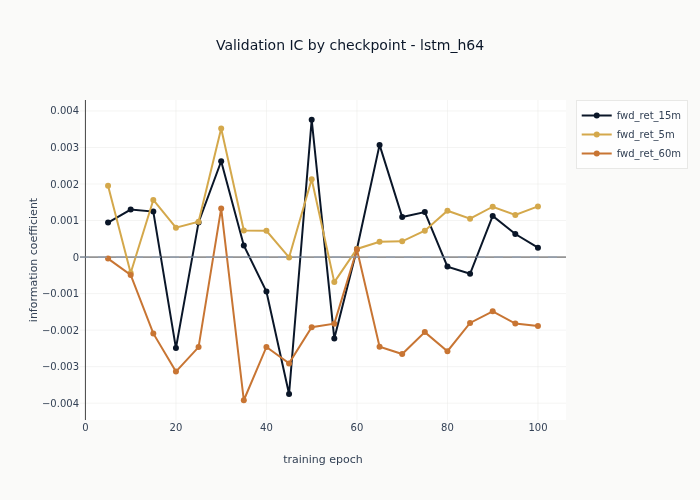

In [10]:
fig = go.Figure()
for _label in catalog["label"].unique().sort().to_list():
    _rows = catalog.filter(pl.col("label") == _label).sort("checkpoint_value")
    fig.add_scatter(
        x=_rows["checkpoint_value"].to_list(),
        y=_rows["ic_mean"].to_list(),
        mode="lines+markers",
        name=_label,
    )
fig.add_hline(y=0, line_width=1, line_dash="dash", line_color=COLORS["recede"])
fig.update_layout(
    title=f"Validation IC by checkpoint - {SEQUENCE_CONFIG}",
    xaxis_title="training epoch",
    yaxis_title="information coefficient",
)
show_plotly_with_alt(
    fig,
    "Validation information coefficient against training epoch, one line per label, with a "
    "dashed line at zero.",
)

## Key takeaways

1. **A checkpoint is part of a configuration, not a detail of how it was fitted.** Scoring one
   fit at twenty points produces twenty candidates, and keeping whichever of them scores
   highest on this page would be a selection decision taken on the wrong statistic: the
   curve below is an information coefficient, and selection is validation backtest Sharpe in
   [`14_backtest`](14_backtest.ipynb), over the population published here.

2. **How many windows are drawn is part of the model.** On a minute panel the cap decides what
   was fitted, so it is declared in `config/setup.yaml` and travels in the training identity
   rather than arriving with the invocation.

3. **A sequence family is measured on fewer rows than a tabular one.** A prediction needs a
   full window behind it, so the samples differ and the comparison has to say so.

**Known limitations.** The window is fixed at sixty observations, so nothing earlier than the
trailing hour reaches the model whatever the architecture can represent. The declared sequence
cap is a compute budget rather than a quantity derived from the data - `config/setup.yaml`
says so - so the same declared count covers a different share of the panel whenever the
panel's size changes.